🔹 1) Import Libraries

In [67]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier


🔹 2) Load Dataset

In [68]:
df = pd.read_csv("heart.csv")
df.head()


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


🔹 3) Dataset Information

In [69]:
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

🔹 4) Exploratory Data Analysis (EDA)

In [70]:
# Binary columns: Sex and ExerciseAngina
df['Sex'] = df['Sex'].map({'M':1,'F':0})
df['ExerciseAngina'] = df['ExerciseAngina'].map({'Y':1,'N':0})

# Convert other categorical columns using One-Hot Encoding
categorical_cols = ['ChestPainType','RestingECG','ST_Slope']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

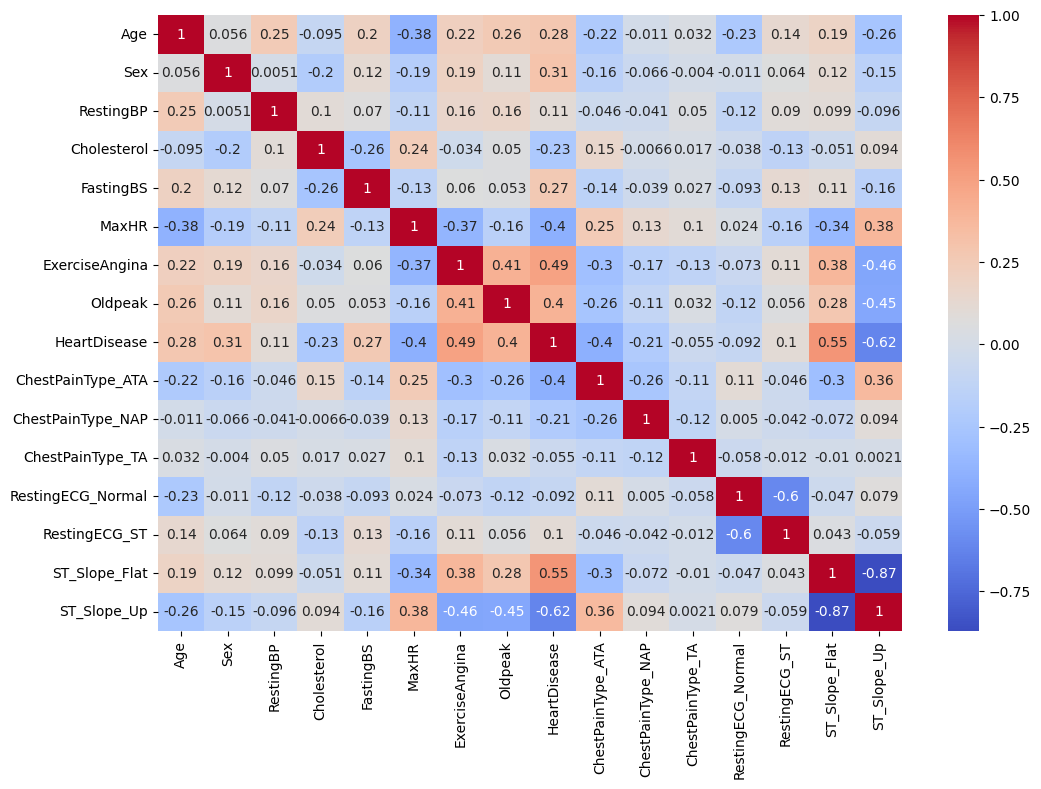

In [71]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()


Count Plot for Target

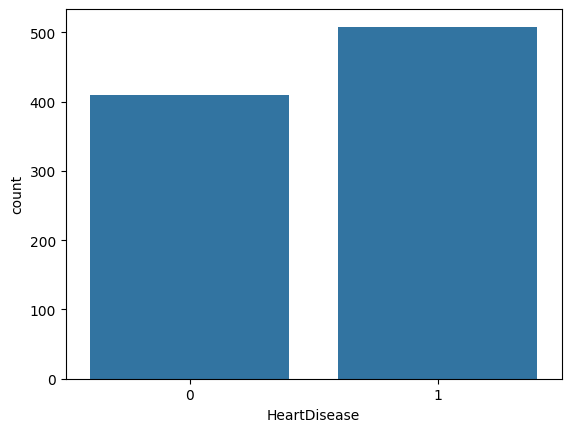

In [72]:
sns.countplot(x='HeartDisease', data=df)
plt.show()


Split Data:

In [73]:
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val)
# Result: 60% train, 20% val, 20% test

🔹 5) Prepare Data

In [74]:
X_train = df.drop('HeartDisease', axis=1)
y_train = df['HeartDisease']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)


🔹 6) Train Multiple Models

1) Logistic Regression

In [75]:
log_model = LogisticRegression()
log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_val)


c:\Users\elssh\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


2) Random Forest

In [76]:
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_val)


3) SVM

In [77]:
svm_model = SVC(probability=True)
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_val)


4) KNN

In [78]:
knn_model = KNeighborsClassifier()
knn_model.fit(X_train, y_train)
knn_pred = knn_model.predict(X_val)


🔹 7) Evaluate Models

In [79]:
def evaluate_model(name, y_val, y_pred):
    print(f"====== {name} ======")
    print("Accuracy:", accuracy_score(y_val, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred))
    print("Classification Report:\n", classification_report(y_val, y_pred))
    print("\n")

evaluate_model("Logistic Regression", y_val, log_pred)
evaluate_model("Random Forest", y_val, rf_pred)
evaluate_model("SVM", y_val, svm_pred)
evaluate_model("KNN", y_val, knn_pred)


====== Logistic Regression ======
Accuracy: 0.8369565217391305
Confusion Matrix:
 [[65 17]
 [13 89]]
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.79      0.81        82
           1       0.84      0.87      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.83      0.83       184
weighted avg       0.84      0.84      0.84       184



====== Random Forest ======
Accuracy: 1.0
Confusion Matrix:
 [[ 82   0]
 [  0 102]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        82
           1       1.00      1.00      1.00       102

    accuracy                           1.00       184
   macro avg       1.00      1.00      1.00       184
weighted avg       1.00      1.00      1.00       184



====== SVM ======
Accuracy: 0.6956521739130435
Confusion Matrix:
 [[57 25]
 [31 71]]
Classification Report:
 

🔹 8) ROC-AUC Score

In [80]:
print("Logistic Regression AUC:", roc_auc_score(y_val, log_model.predict_proba(X_val)[:,1]))
print("Random Forest AUC:", roc_auc_score(y_val, rf_model.predict_proba(X_val)[:,1]))
print("SVM AUC:", roc_auc_score(y_val, svm_model.predict_proba(X_val)[:,1]))
print("KNN AUC:", roc_auc_score(y_val, knn_model.predict_proba(X_val)[:,1]))


Logistic Regression AUC: 0.899689143950263
Random Forest AUC: 1.0
SVM AUC: 0.7606408417025345
KNN AUC: 0.8652558584409374


🔹 9) Choose Best Model

In [81]:
# Example: choosing Random Forest
best_model = rf_model


🔹 10) Predict for New Patient

In [82]:
test_pred = best_model.predict(X_test)
print("Test Predictions:", test_pred)
print("Test Accuracy:", accuracy_score(y_test, test_pred))

Test Predictions: [1 1 1 1 0 0 0 1 0 1 1 0 0 0 0 1 0 1 0 1 0 1 0 0 1 1 0 1 1 0 0 1 0 0 1 1 1
 1 0 1 1 1 1 0 1 1 1 0 1 0 0 0 0 0 1 0 1 0 0 0 0 1 0 1 0 1 1 1 0 0 0 1 0 1
 0 1 1 1 1 1 1 1 1 0 1 0 1 1 0 1 0 1 0 0 0 1 1 1 0 1 1 1 1 0 1 1 1 1 0 1 1
 0 0 1 1 1 1 0 0 1 0 1 0 0 0 1 0 1 1 0 0 0 0 0 1 1 1 0 1 0 1 1 0 0 1 1 0 0
 1 1 1 0 1 0 1 1 0 0 1 1 0 1 0 0 1 0 1 1 0 1 1 0 1 1 0 1 0 0 1 0 1 1 1 1]
Test Accuracy: 1.0
